In [1]:
import asyncio
import json
import time
from urllib.request import urlopen
import urllib.request
import hid
import serial
import serial.tools.list_ports
import websockets
import copy
from windfreak import SynthHD
from RsInstrument import RsInstrument, BinFloatFormat
import skrf as rf
import matplotlib.pyplot as plt
import numpy as np
import pyvisa
from datetime import datetime
from pathlib import Path
import os
import sys

rm = pyvisa.ResourceManager()
instruments = rm.list_resources()

vna = None
for instrument in instruments:
    if 'Rohde' in instrument:
        # Initialize instrument
        vna = RsInstrument(instrument, id_query=True, reset=False) 
        break
print(vna.query('*IDN?').strip())
vna.go_to_local()


Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30


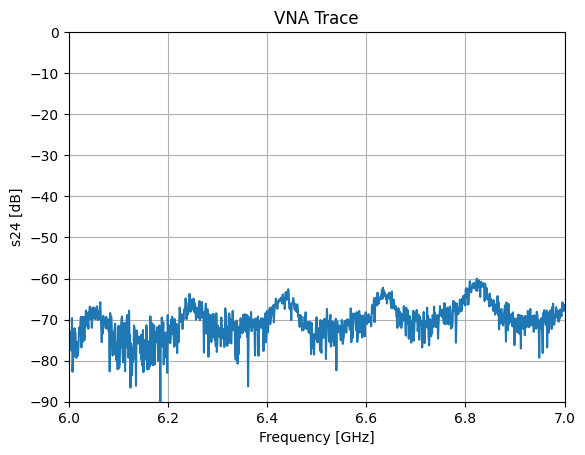

In [2]:
with open("state.json", "r") as f:
    state = json.load(f)
    
now = datetime.now().astimezone()
state['timestamp'] = int(now.timestamp())
state['date'] = now.strftime("%d-%m-%Y")
state['time'] = now.strftime("%H:%M:%S")
state['timezone'] = now.tzname()


mixing_chamber_temperature_url = 'http://132.163.130.19/bluefors-fridge-log-server/mixing_chamber_temperature.json'
try:
    with urllib.request.urlopen(mixing_chamber_temperature_url) as response:
        text_data = response.read().decode('utf-8')
        mixing_chamber_temperature = json.loads(text_data)
except Exception as e:
    print(f"An error occurred: {e}")

state['temperature'] = mixing_chamber_temperature['temperature']

try:
    script_dir = Path(__file__).resolve().parent
except NameError:
    script_dir = Path.cwd()
folder_name = datetime.now().strftime("%d-%m-%Y")
target_dir = script_dir / folder_name
target_dir.mkdir(parents=True, exist_ok=True)

readme_path = target_dir / 'README.md'
if not readme_path.exists():
    readme_path.write_text("#  " + state['date'] + " Plots\n\n")

if 'vna' in state['measurement_select']:
    frequencies = np.linspace(state['vna_start_frequency'],state['vna_stop_frequency'],state['vna_number_of_points'])
    fghz = frequencies/1e9
    vna.bin_float_numbers_format = BinFloatFormat.Single_4bytes
    vna.write("FORM REAL,32") 
    vna.write_str(":CALC1:PAR:SEL 'Trc1'") 
    vna.write("INITiate:CONTinuous OFF")
    vna.write("INITiate:IMMediate")  
    opc_done = vna.query("*OPC?").strip()    
    if opc_done != "1":
        print(f"Error: OPC returned unexpected value '{opc_done}'; ending execution.")
        exit()
    raw_floats = vna.query_bin_or_ascii_float_list(":CALC1:DATA? SDAT")
    vna.write("INITiate:CONTinuous ON")
    vna.go_to_local()
    real_parts = np.array(raw_floats[0::2])
    imag_parts = np.array(raw_floats[1::2])
    complex_trace = real_parts + 1j * imag_parts
    s_matrix = np.zeros((len(frequencies), 1, 1), dtype=complex)
    s_matrix[:, 0, 0] = complex_trace
    trace_network = rf.Network(frequency=frequencies, s=s_matrix, name='data trace')
    trace = trace_network.s_db[:,0,0]
    plt.plot(fghz, trace)
    plt.xlim(fghz[0], fghz[-1])
    plt.ylim(state['vna_plot_scale_minimum'],state['vna_plot_scale_maximum'])
    plt.ylim(-90,0)
    plt.title(state['vna_plot_title'])
    plt.grid()
    plt.xlabel('Frequency [GHz]')
    plt.ylabel(state['s_parameter_select'] + ' [dB]')
    plot_file_name = f"{state['timestamp']}-vna-plot.png"
    plot_file_path = target_dir / plot_file_name
    plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
    touchstone_file_name = f"{state['timestamp']}-vna-trace.s1p"
    touchstone_file_path = target_dir / touchstone_file_name
    trace_network.write_touchstone(str(touchstone_file_path))
    with open(readme_path, "a") as file:
        file.write("![]("+ plot_file_name + ")\n")
    
if 'spectrum_analyzer' in state['measurement_select']:
    frequencies = np.linspace(state['spa_start_frequency'],state['spa_stop_frequency'],state['spa_number_of_points'])
    fghz = frequencies/1e9
    spa.write(":UNIT:POW W")
    spa.write("FORM REAL,32")
    spa.write("INIT:CONT OFF")
    spa.timeout = 30000    
    spa.write("INIT:IMM")
    spa.query("*OPC?")
    spa.timeout = 5000
    spa_trace = np.array(spa.query_binary_values("TRAC? TRACE1", datatype="f", is_big_endian=True))
    spa.write("INIT:CONT ON")
    plt.plot(fghz, spa_trace/1e-12)
    plt.xlim(fghz[0], fghz[-1])
    plt.ylim(state['spa_plot_minimum'], state['spa_plot_maximum'])
    plt.grid()
    plt.xlabel('Frequency [GHz]')
    plt.title(state['spa_plot_title'])
    plt.ylabel(state['spa_ylabel'])
    
    plot_file_name = f"{state['timestamp']}-spa-plot.png"
    plot_file_path = target_dir / plot_file_name
    plt.savefig(plot_file_path, dpi=300, bbox_inches='tight')
    trace_file_name = f"{state['timestamp']}-spa-trace.json"
    file_path = target_dir / trace_file_name
    spa_trace_data  = {}
    spa_trace_data['fghz']  = fghz.tolist()
    spa_trace_data['trace'] = (spa_trace/1e-12).tolist()
    spa_trace_data['unit'] = "pW"
    spa_trace_data['vbw'] = state['spa_video_bandwidth']
    spa_trace_data['rbw'] = state['spa_resolution_bandwidth']
    with open(readme_path, "a") as file:
        file.write("![]("+ plot_file_name + ")\n")
    with open(file_path, "w", encoding="utf-8") as f:
        json.dump(spa_trace_data, f, indent=4)
    
state_file_name = f"{state['timestamp']}-state.json"

with open(readme_path, "a") as file:
    file.write("[" + state_file_name + "]("+ state_file_name + ")\n")


state['file_name'] = state_file_name
state['state_file_url'] = state['data_url_base'] + folder_name + "/" +  state['file_name']
file_path = target_dir / state_file_name
with open(file_path, "w", encoding="utf-8") as f:
    json.dump(state, f, indent=4)

main_state_file_name = "state.json"
file_path = script_dir / main_state_file_name
with open(file_path, "w", encoding="utf-8") as f:
    json.dump(state, f, indent=4)

In [12]:
state

{'vna_idn': 'Rohde&Schwarz,ZVA24-2Port,1145111024100131,3.30',
 'vna_source_power': 0,
 'vna_if_bandwidth': 1000,
 'vna_start_frequency': 4000000000,
 'vna_stop_frequency': 8000000000,
 'vna_number_of_points': 1001,
 'vna_plot_scale_minimum': -80,
 'vna_plot_scale_maximum': -40,
 'vna_plot_title': 'VNA Trace',
 'spa_resolution_bandwidth': 5000000,
 'spa_video_bandwidth': 10000,
 'spa_units': 'W',
 'spa_idn': 'Hewlett-Packard, E7405A, SG45102671, A.14.04',
 'spa_start_frequency': 4000000000,
 'spa_stop_frequency': 8000000000,
 'spa_number_of_points': 1001,
 'spa_plot_title': 'Spectrum Analyzer Trace',
 'spa_plot_minimum': 0,
 'spa_plot_maximum': 1500,
 'spa_ylabel': 'Noise Power [pW]',
 's_parameter_select': 's24',
 'measurement_select': 'vna',
 'twpa_pump_select': 'twpa_pump_1',
 'programmable_attenuator': 0,
 'temperature': 46.01739,
 'date': '19-08-2026',
 'time': '12:53:08',
 'timestamp': 1787165588,
 'data_repository': 'https://github.com/lafefspietz/jpa-twpa-qubit-noise-summer-202

In [19]:
vna.close()